# Analyse contrail climate impact of 2019 European departures

1. Setup 
2. Contrail forcing by departure time of day and month of year 
3. Contrail forcing by departure airport
4. Contrail forcing by departure FIR 
5. Number of big hits by day and airport
6. Number of big hits by day and FIR

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Read file with flight schedules + contrail information on a flight-by-flight level
df = pd.read_parquet(r"C:\Users\TE\Documents\Datasets\icl/2019 - Jet-A - Flight Summary.pq")

# Density of conventional jet fuel
density_kerosene = 0.81 # kg/l

# CO2 emitted per kilogram of jet fuel
CO2_per_kg_fuel  = 3.168  # kg_CO2/kg_jet_a1

# Total surface area of Earth
earth_surface_area = 5.101e14  # m^2

# CO2 absolute global warming potential over 20 years
CO2_agwp_20_years  = 2.39e-14  # yr W m^-2 kg^-2

# CO2 absolute global warming potential over 100 years
CO2_agwp_100_years = 8.8e-14  # yr W m^-2 kg^-2

# Number of seconds in a year
seconds_per_year   = 365 * 24 * 60 * 60  # s/yr

# Effective radiative forcing to radiative forcing ratio
ERF_RF_ratio = 0.42

# Conversion factors to convert fuel burn to forcing through CO2
fuel_to_co2_forcing_20  = CO2_per_kg_fuel * earth_surface_area * CO2_agwp_20_years  * seconds_per_year
fuel_to_co2_forcing_100 = CO2_per_kg_fuel * earth_surface_area * CO2_agwp_100_years * seconds_per_year

def attach_gwp_from_fuel_burn(df): 
    # Calculate tailpipe CO2 emissions, AGWP and GWP
    df["total_co2"]              = df["total_fuel_burn"] * CO2_per_kg_fuel
    df["total_co2_forcing_20"]   = df["total_fuel_burn"] * fuel_to_co2_forcing_20
    df["total_co2_forcing_100"]  = df["total_fuel_burn"] * fuel_to_co2_forcing_100
    df["gwp20"]                  = df["total_contrail_energy_forcing"] / df["total_co2_forcing_20"]   * ERF_RF_ratio
    df["gwp100"]                 = df["total_contrail_energy_forcing"] / df["total_co2_forcing_100"]  * ERF_RF_ratio

# Compute GWP20/GWP100 for df
attach_gwp_from_fuel_burn(df)


# Attach one of the labels "Cooling", "No contrail", "Big hit" or "Other warming" to every flight
def label_by_contrail_warming(df, big_hit_threshold = 0.8): 
    # Compute which flights generate 80% of total contrail warming
    sorted_df   = df.sort_values(by="total_contrail_energy_forcing", ascending=False)
    cumulative  = sorted_df["total_contrail_energy_forcing"].cumsum()
    normalized  = cumulative / cumulative.iloc[-1]
    # Entries in normalized indicated which warming percentile a given flight is at
    eighty_idx  = (normalized >= big_hit_threshold).to_numpy().argmax()
    big_hits    = sorted_df.iloc[:eighty_idx]
    big_hit_ids = big_hits["flight_id"].unique().tolist()

    # Assign warming types
    df["warming_type"] = np.where(df["mean_contrail_lifetime"].isna(), "No contrail", "Other warming")
    df.loc[df["total_contrail_energy_forcing"] < 0, "warming_type"] = "Cooling"
    df.loc[df["flight_id"].isin(big_hit_ids), "warming_type"] = "Big hit"

    # Create indicator columns for better performance
    df = df.assign(
    is_big_hit    =(df["warming_type"] == "Big hit").astype(int),
    is_warming    =(df["warming_type"] == "Warming").astype(int),
    is_cooling    =(df["warming_type"] == "Cooling").astype(int),
    is_no_contrail=(df["warming_type"] == "No contrail").astype(int)
    )


label_by_contrail_warming(df)

# Create indicator columns for better performance
df = df.assign(
is_big_hit    =(df["warming_type"] == "Big hit").astype(int),
is_warming    =(df["warming_type"] == "Warming").astype(int),
is_cooling    =(df["warming_type"] == "Cooling").astype(int),
is_no_contrail=(df["warming_type"] == "No contrail").astype(int)
)

# Add months and hours for grouping operations
df["time"]   = pd.to_datetime(df["first_waypoint_time" ], errors="coerce")
df["date"]   = df["time"].dt.date
df["month"]  = df["time"].dt.month
df["hour"]   = df["time"].dt.hour


# Map countries to regions
countries = pd.read_csv("data/countries.csv")
iso2_to_region = countries.set_index('alpha-2')['region'].to_dict()
df['origin_region'] = df['origin_country'].map(iso2_to_region)

# Filter European departures only since the file also contains incoming flights
df = df[df["origin_region"] == "Europe"]

In [7]:
df.head()

,flight_id,aircraft_type_icao,aircraft_engine_type,origin_airport,origin_airport_name,origin_country,destination_airport,destination_airport_name,destination_country,first_waypoint_time,...,warming_type,time,date,month,hour,origin_region,is_big_hit,is_warming,is_cooling,is_no_contrail
8,190101-10273-TAP005,A343,Jet,LPPT,Humberto Delgado Airport (Lisbon Portela Airport),PT,SBSG,São Gonçalo do Amarante - Governador Aluízio A...,BR,2019-01-01 00:14:31.000,...,No contrail,2019-01-01 00:14:31.000,2019-01-01,1,0,Europe,0,0,0,1
453,190101-15431-CCA722,A332,Jet,LHBP,Budapest Liszt Ferenc International Airport,HU,ZBAA,Beijing Capital International Airport,CN,2019-01-01 00:01:57.000,...,No contrail,2019-01-01 00:01:57.000,2019-01-01,1,0,Europe,0,0,0,1
1163,190101-2240-IBE2601,A332,Jet,LEBL,Josep Tarradellas Barcelona-El Prat Airport,ES,SAEZ,Ministro Pistarini International Airport,AR,2019-01-01 00:31:09.545,...,No contrail,2019-01-01 00:31:09.545,2019-01-01,1,0,Europe,0,0,0,1
1387,190101-2558-AFR6744,B77L,Jet,LFPG,Charles de Gaulle International Airport,FR,DRRN,Diori Hamani International Airport,NE,2019-01-01 00:01:45.000,...,No contrail,2019-01-01 00:01:45.000,2019-01-01,1,0,Europe,0,0,0,1
1601,190101-28265-ETD88F,B77W,Jet,EDDM,Munich Airport,DE,OMAA,Abu Dhabi International Airport,AE,2019-01-01 00:39:21.000,...,No contrail,2019-01-01 00:39:21.000,2019-01-01,1,0,Europe,0,0,0,1


## 2. Compute contrail forcing by departure month and hour for European departures

In [ ]:
MONTHS = range(1, 13)
HOURS = range(24)

def aggregate_contrail_forcing(df, group_col):

    # --- Aggregate total forcing ---
    forcing = (
        df.groupby([group_col, "warming_type"], dropna=True)
          ["total_contrail_energy_forcing"]
          .sum()
          .unstack(fill_value=0)
    )

    # --- Count number of flights ---
    flights = (
        df.groupby([group_col, "warming_type"], dropna=True)
          .size()
          .unstack(fill_value=0)
          .add_suffix("_flights")
    )

    # --- Combine both ---
    result = pd.concat([forcing, flights], axis=1).reset_index()

    return result

In [41]:
# Aggregate by month
monthly = aggregate_contrail_forcing(df, "month")

# Step 1. Rename columns neatly for visualization
monthly = monthly.rename(columns={
    "warming_type": "Warming Type",
    "month": "Month",
    "Big hit": "Big hit warming",
    "Cooling": "Cooling",
    "No contrail": "No contrail",
    "Other warming": "Other warming",
    "Big hit_flights": "Big Hit Flights",
    "Cooling_flights": "Cooling Flights",
    "No contrail_flights": "No Contrail Flights",
    "Other warming_flights": "Other Warming Flights"
})

# Step 2. Map month numbers (1–12) to month names
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}
monthly["Month"] = monthly["Month"].map(month_map)

# Step 3. Add total columns
monthly["Total warming"] = (
    monthly["Big hit warming"] +
    monthly["Cooling"] +
    monthly["No contrail"] +
    monthly["Other warming"]
)

monthly["Total number of flights"] = (
    monthly["Big Hit Flights"] +
    monthly["Cooling Flights"] +
    monthly["No Contrail Flights"] +
    monthly["Other Warming Flights"]
)


# Step 4. Select and reorder columns for visualization
cols_to_keep = [
    "Month",
    "Total number of flights",          # normalized version of Total Flights
    "Big hit warming",        # normalized Big Hit Warming
    "Other warming",          # normalized Other Warming
    "Cooling"                 # normalized Cooling
]


normalized = monthly[cols_to_keep].copy()
normalized["Total number of flights"] /= (1/100) * monthly["Total number of flights"].sum()
normalized["Big hit warming"]         /= (1/100) * monthly["Total warming"].sum()
normalized["Other warming"]           /= (1/100) * monthly["Total warming"].sum()
normalized["Cooling"]                 /= (1/100) * monthly["Total warming"].sum()

normalized = normalized.round(1)

# Export to CSV
normalized.to_csv("output/departures/1_big_hits_by_month.csv", index=False)

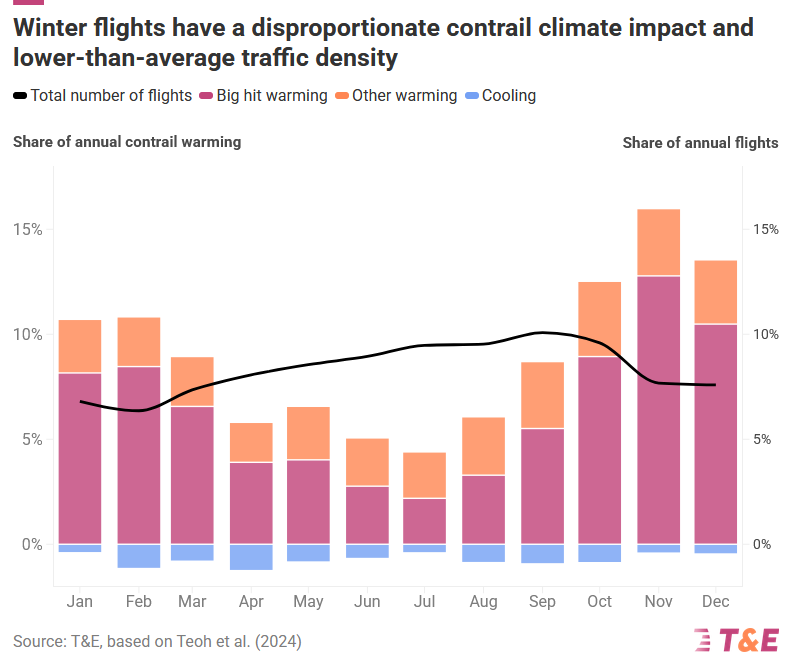

In [ ]:

# Aggregate by hour
hourly = aggregate_contrail_forcing(df, "hour")


# Step 1. Rename columns neatly for visualization
hourly = hourly.rename(columns={
    "warming_type": "Warming Type",
    "hour": "Hour",
    "Big hit": "Big hit warming",
    "Cooling": "Cooling",
    "No contrail": "No contrail",
    "Other warming": "Other warming",
    "Big hit_flights": "Big Hit Flights",
    "Cooling_flights": "Cooling Flights",
    "No contrail_flights": "No Contrail Flights",
    "Other warming_flights": "Other Warming Flights"
})

# Step 2. Add total columns
hourly["Total warming"] = (
    hourly["Big hit warming"] +
    hourly["Cooling"] +
    hourly["No contrail"] +
    hourly["Other warming"]
)

hourly["Total number of flights"] = (
    hourly["Big Hit Flights"] +
    hourly["Cooling Flights"] +
    hourly["No Contrail Flights"] +
    hourly["Other Warming Flights"]
)


# Step 3. Select and reorder columns for visualization
cols_to_keep = [
    "Hour",
    "Total number of flights",          # normalized version of Total Flights
    "Big hit warming",        # normalized Big Hit Warming
    "Other warming",          # normalized Other Warming
    "Cooling"                 # normalized Cooling
]


normalized = hourly[cols_to_keep].copy()
normalized["Total number of flights"] /= (1/100) * hourly["Total number of flights"].sum()
normalized["Big hit warming"]         /= (1/100) * hourly["Total warming"].sum()
normalized["Other warming"]           /= (1/100) * hourly["Total warming"].sum()
normalized["Cooling"]                 /= (1/100) * hourly["Total warming"].sum()
normalized = normalized.round(1)

# Export to CSV
normalized.to_csv("output/departures/2_big_hits_by_hour.csv", index=False)

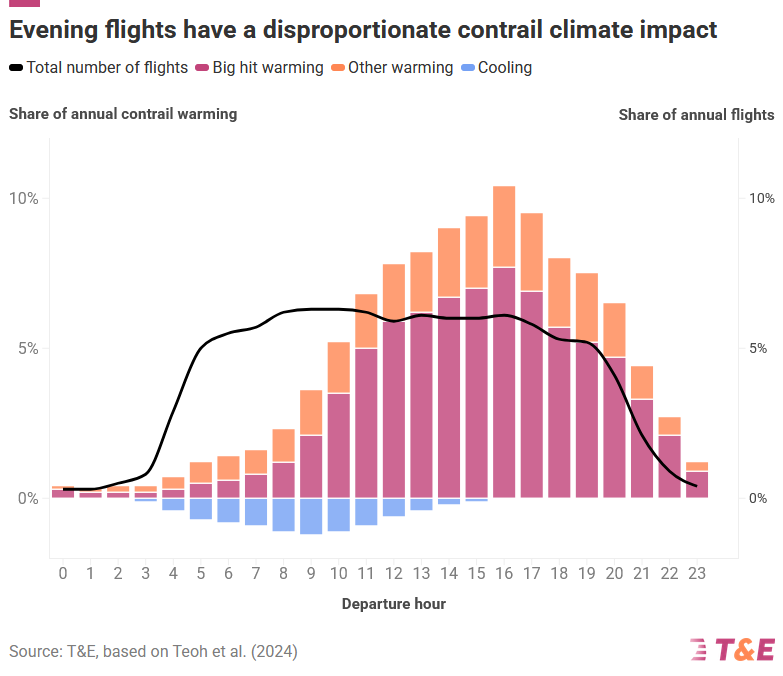

## 3. Big hits by day and airport

In [42]:

# Aggregate by date and FIR
airport_daily_full = (
    df.groupby(["date", "origin_airport_name"], as_index=False)
    .agg(
        n_total=("flight_id", "count"),
        n_big_hit=("is_big_hit", "sum"),
        n_warming=("is_warming", "sum"),
        n_cooling=("is_cooling", "sum"),
        n_no_contrail=("is_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)


# --- 1️⃣ Find top 10 airports by total fuel burn ---
# Storing the daily data for all airports results in a very big file
top_airports = (
    df.groupby("origin_airport_name", as_index=False)["total_fuel_burn"]
      .sum()
      .nlargest(3, "total_fuel_burn")["origin_airport_name"]
)

# --- 2️⃣ Filter the dataframe ---
airport_daily_simple = airport_daily_full[airport_daily_full["origin_airport_name"].isin(top_airports)]


airport_daily_simple = airport_daily_simple[[
    "date", "origin_airport_name", "n_big_hit"
]].rename(columns={"date": "Date", "origin_airport_name": "Departure airport", "n_big_hit": "Number of big hits"})


airport_daily_simple.to_csv("output/departures/3_daily_big_hits_by_airport.csv", index=False)


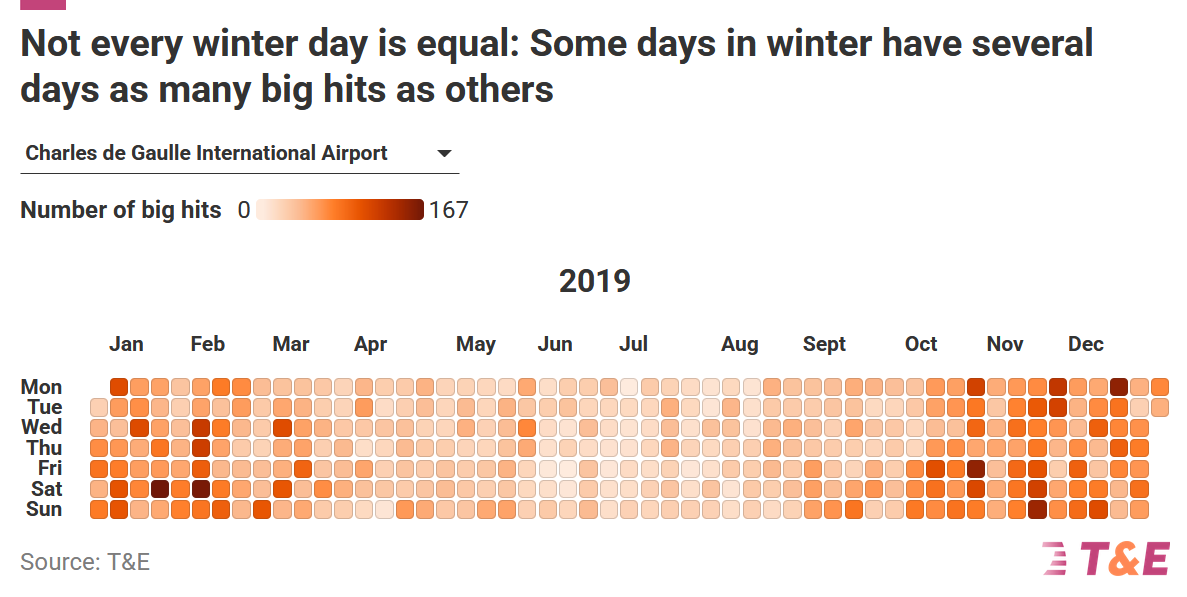

In [ ]:

# Sum across days by FIR
airport_totals = (
    airport_daily_full.groupby(["origin_airport_name"], as_index=False)
    .agg(
        n_total=("n_total", "sum"),
        n_big_hit=("n_big_hit", "sum"),
        n_warming=("n_warming", "sum"),
        n_cooling=("n_cooling", "sum"),
        n_no_contrail=("n_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)
attach_gwp_from_fuel_burn(airport_totals)
airport_totals.to_csv("output/departures/4_warming_by_airport.csv", index=False)

## 4. Big hits by day and FIR

In [ ]:
import json
import geopandas as gpd, topojson

# Load flight information region boundaries 
with open(r"data/worldfirs.json") as f:
    topo = json.load(f)

gdf = (
    topojson.Topology(topo, object_name="data")
        .to_gdf()
        .set_crs(4326)           # WGS-84
)

# Filter only FIRs (and not so-called upper information regions (UIRs))
gdf = gdf[gdf["type"].str.contains("FIR")]

# Filter out European FIRs
european_fir = pd.read_csv("data/european_firs.csv")
gdf = gdf[gdf["designator"].isin(european_fir["FIR code"])]

# Load airports
airports = pd.read_csv("data/airports.csv")

# Keep only the needed columns and rename for clarity
airports = airports.rename(columns={
    "icao": "origin_airport",
})

# Convert airports DataFrame to GeoDataFrame
airports_gdf = gpd.GeoDataFrame(
    airports,
    geometry=gpd.points_from_xy(airports.longitude, airports.latitude),
    crs="EPSG:4326"  # WGS84
)

# Match each airport to its FIR polygon
airports_with_fir = gpd.sjoin(
    airports_gdf,
    gdf[["geometry", "designator", "name"]],
    how="left",
    predicate="within"
)

# Rename columns for clarity
airports_with_fir = airports_with_fir.rename(columns={
    "designator": "fir_code",
    "name_right": "fir_name"
})

# Make sure FIRs are attached
df_europe = df.merge(
    airports_with_fir[["origin_airport", "fir_code", "fir_name"]],
    on="origin_airport",
    how="left"
)

# Aggregate by date and FIR
fir_daily_full = (
    df_europe.groupby(["date", "fir_code", "fir_name"], as_index=False)
    .agg(
        n_total=("flight_id", "count"),
        n_big_hit=("is_big_hit", "sum"),
        n_warming=("is_warming", "sum"),
        n_cooling=("is_cooling", "sum"),
        n_no_contrail=("is_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)

fir_daily_simple = fir_daily_full[[
    "date", "fir_code", "fir_name", "n_big_hit"
]].rename(columns={"date": "Date", "fir_code": "FIR code", "fir_name": "FIR", "n_big_hit": "Number of big hit departures"})

fir_daily_simple.to_csv("output/departures/5_daily_big_hits_by_fir.csv", index=False)

                                            geometry designator type  upper  \
0  POLYGON ((159.0001 -4.83327, 156.03334 -6.5499...       AGGG  FIR    NaN   
1  POLYGON ((160.00018 9.00001e-5, 160.00018 -1.4...       ANAU  FIR    NaN   
2  POLYGON ((141.00008 9.00001e-5, 141.00008 -2.5...       AYPM  FIR    NaN   
3  POLYGON ((-60 90, -60 86.99994, -60 84.99995, ...       BGGL  FIR    NaN   
4  POLYGON ((-5.49991 60.99999, -5.14639 60.99999...       BIRD  FIR    NaN   

   lower              name  
0    0.0       Honiara FIR  
1    0.0         Nauru FIR  
2    0.0  Port Moresby FIR  
3    0.0          Nuuk FIR  
4    0.0     Reykjavik FIR  
                                             geometry designator type  upper  \
4   POLYGON ((-5.49991 60.99999, -5.14639 60.99999...       BIRD  FIR    NaN   
20  POLYGON ((3.0069 51.40526, 2.50002 51.45548, 2...       EBBU  FIR  195.0   
22  POLYGON ((9.62443 48.62138, 9.68635 48.6986, 9...       EDGG  FIR  245.0   
23  POLYGON ((9.54991 47.83334,

In [ ]:

# Sum across days by FIR
fir_totals = (
    fir_daily_full.groupby(["fir_code", "fir_name"], as_index=False)
    .agg(
        n_total=("n_total", "sum"),
        n_big_hit=("n_big_hit", "sum"),
        n_warming=("n_warming", "sum"),
        n_cooling=("n_cooling", "sum"),
        n_no_contrail=("n_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)
attach_gwp_from_fuel_burn(fir_totals)
fir_totals.to_csv("output/departures/6_warming_by_fir.csv", index=False)